In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.utils.class_weight import compute_class_weight

print(f"TensorFlow version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs available: {gpus if gpus else 'None — using CPU'}")
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

TensorFlow version: 2.20.0
GPUs available: None — using CPU


In [8]:
# ── Paths ─────────────────────────────────────────────────
OUTPUT_DIR = r"C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\DS1_split"
TRAIN_DIR  = os.path.join(OUTPUT_DIR, "TRAIN")
TEST_DIR   = os.path.join(OUTPUT_DIR, "TEST")

# ── Hyperparameters ───────────────────────────────────────
IMG_SIZE      = (224, 224)
BATCH_SIZE    = 32
EPOCHS_FROZEN = 15
EPOCHS_FINE   = 20
LR_FROZEN     = 1e-3
LR_FINE       = 1e-5

# ── Classes ───────────────────────────────────────────────
CLASS_NAMES   = ["N", "O", "R"]
DISPLAY_NAMES = ["Non-Recyclable", "Organic", "Recyclable"]
NUM_CLASSES   = len(CLASS_NAMES)

MODEL_SAVE_PATH = r"C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\waste_efficientnetb0_final(split).keras"

print("Config loaded ✅")
print(f"Train dir: {TRAIN_DIR}")
print(f"Test  dir: {TEST_DIR}")

# Verify counts
print("\nVerifying dataset:")
for split, d in [("TRAIN", TRAIN_DIR), ("TEST", TEST_DIR)]:
    print(f"\n  {split}:")
    for cls in CLASS_NAMES:
        count = len(os.listdir(os.path.join(d, cls)))
        print(f"    {cls}: {count} images")

Config loaded ✅
Train dir: C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\DS1_split\TRAIN
Test  dir: C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\DS1_split\TEST

Verifying dataset:

  TRAIN:
    N: 3881 images
    O: 11172 images
    R: 11936 images

  TEST:
    N: 971 images
    O: 2794 images
    R: 2985 images


In [9]:
# ════════════════════════════════════════════════════════════
# STEP 1 — DATA GENERATORS
# ════════════════════════════════════════════════════════════
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.10,
    zoom_range=0.20,
    horizontal_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest",
)

test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=True,
    seed=42,
)

test_gen = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    classes=CLASS_NAMES,
    shuffle=False,
)

print(f"\nClass indices : {train_gen.class_indices}")
print(f"Train samples : {train_gen.samples}")
print(f"Test  samples : {test_gen.samples}")

Found 26979 images belonging to 3 classes.
Found 6749 images belonging to 3 classes.

Class indices : {'N': 0, 'O': 1, 'R': 2}
Train samples : 26979
Test  samples : 6749


In [10]:
# ════════════════════════════════════════════════════════════
# STEP 2 — CLASS WEIGHTS
# ════════════════════════════════════════════════════════════
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_gen.classes
)
class_weight_dict = dict(enumerate(class_weights))
print(f"\nClass weights: {class_weight_dict}")


Class weights: {0: np.float64(2.3231723068974426), 1: np.float64(0.8049588256355173), 2: np.float64(0.7534349865951743)}


In [11]:
# ════════════════════════════════════════════════════════════
# STEP 3 — BUILD MODEL
# ════════════════════════════════════════════════════════════
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(*IMG_SIZE, 3),
)
base_model.trainable = False   # freeze for Phase 1

inputs  = tf.keras.Input(shape=(*IMG_SIZE, 3))
x       = base_model(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.BatchNormalization()(x)
x       = layers.Dense(256, activation="relu")(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation="relu")(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = models.Model(inputs, outputs, name="WasteClassifier_EfficientNetB0")

print(f"\nTotal params    : {model.count_params():,}")
print(f"Trainable params: {sum(tf.size(v).numpy() for v in model.trainable_variables):,}")
model.summary()


Total params    : 4,415,910
Trainable params: 363,779


Model: "WasteClassifier_EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,415,910 (16.85 MB)

 Trainable params: 363,779 (1.39 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

In [13]:
# ════════════════════════════════════════════════════════════
# STEP 4 — PHASE 1: Train Head Only
# ════════════════════════════════════════════════════════════
model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_FROZEN),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

cb_phase1 = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=3, min_lr=1e-7, verbose=1),
    callbacks.ModelCheckpoint("best_phase1_efficientnet(split).keras", monitor="val_accuracy",
                              save_best_only=True, verbose=1),
]

print("\nPhase 1 — Training head only (base frozen)")
history1 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS_FROZEN,
    callbacks=cb_phase1,
    class_weight=class_weight_dict,
)


Phase 1 — Training head only (base frozen)
Epoch 1/15
 60/844 ━━━━━━━━━━━━━━━━━━━━ 7:24 567ms/step - accuracy: 0.8207 - loss: 0.4669

c:\tools\Anaconda3\envs\myenv\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


214/844 ━━━━━━━━━━━━━━━━━━━━ 5:48 553ms/step - accuracy: 0.8188 - loss: 0.4901

c:\tools\Anaconda3\envs\myenv\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 551ms/step - accuracy: 0.8305 - loss: 0.4574
Epoch 1: val_accuracy improved from None to 0.90324, saving model to best_phase1_efficientnet(split).keras

Epoch 1: finished saving model to best_phase1_efficientnet(split).keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 548s 640ms/step - accuracy: 0.8442 - loss: 0.4156 - val_accuracy: 0.9032 - val_loss: 0.2735 - learning_rate: 0.0010
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 531ms/step - accuracy: 0.8808 - loss: 0.3316
Epoch 2: val_accuracy did not improve from 0.90324
844/844 ━━━━━━━━━━━━━━━━━━━━ 518s 614ms/step - accuracy: 0.8821 - loss: 0.3274 - val_accuracy: 0.8970 - val_loss: 0.2821 - learning_rate: 0.0010
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.8963 - loss: 0.2885
Epoch 3: val_accuracy improved from 0.90324 to 0.92503, saving model to best_phase1_efficientnet(split).keras

Epoch 3: finished saving model to best_phase1_efficientnet(split).keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 520s 616ms/ste

In [14]:
# ════════════════════════════════════════════════════════════
# STEP 5 — PHASE 2: Fine-tune Top 20 Layers
# ════════════════════════════════════════════════════════════
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=LR_FINE),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

cb_phase2 = [
    callbacks.EarlyStopping(monitor="val_accuracy", patience=5,
                            restore_best_weights=True, verbose=1),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5,
                                patience=3, min_lr=1e-8, verbose=1),
    callbacks.ModelCheckpoint("best_phase2_efficientnet(split).keras", monitor="val_accuracy",
                              save_best_only=True, verbose=1),
]

print("\nPhase 2 — Fine-tuning top 20 layers of EfficientNetB0")
history2 = model.fit(
    train_gen,
    validation_data=test_gen,
    epochs=EPOCHS_FINE,
    callbacks=cb_phase2,
    class_weight=class_weight_dict,
)


Phase 2 — Fine-tuning top 20 layers of EfficientNetB0
Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 577ms/step - accuracy: 0.8998 - loss: 0.2662
Epoch 1: val_accuracy improved from None to 0.92177, saving model to best_phase2_efficientnet(split).keras

Epoch 1: finished saving model to best_phase2_efficientnet(split).keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 572s 667ms/step - accuracy: 0.9077 - loss: 0.2522 - val_accuracy: 0.9218 - val_loss: 0.2156 - learning_rate: 1.0000e-05
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 581ms/step - accuracy: 0.9170 - loss: 0.2263
Epoch 2: val_accuracy improved from 0.92177 to 0.92606, saving model to best_phase2_efficientnet(split).keras

Epoch 2: finished saving model to best_phase2_efficientnet(split).keras
844/844 ━━━━━━━━━━━━━━━━━━━━ 564s 668ms/step - accuracy: 0.9186 - loss: 0.2177 - val_accuracy: 0.9261 - val_loss: 0.2099 - learning_rate: 1.0000e-05
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 0s 580ms/step - accuracy: 0.9222 - loss: 0.2077
Epoch 3: val_accurac

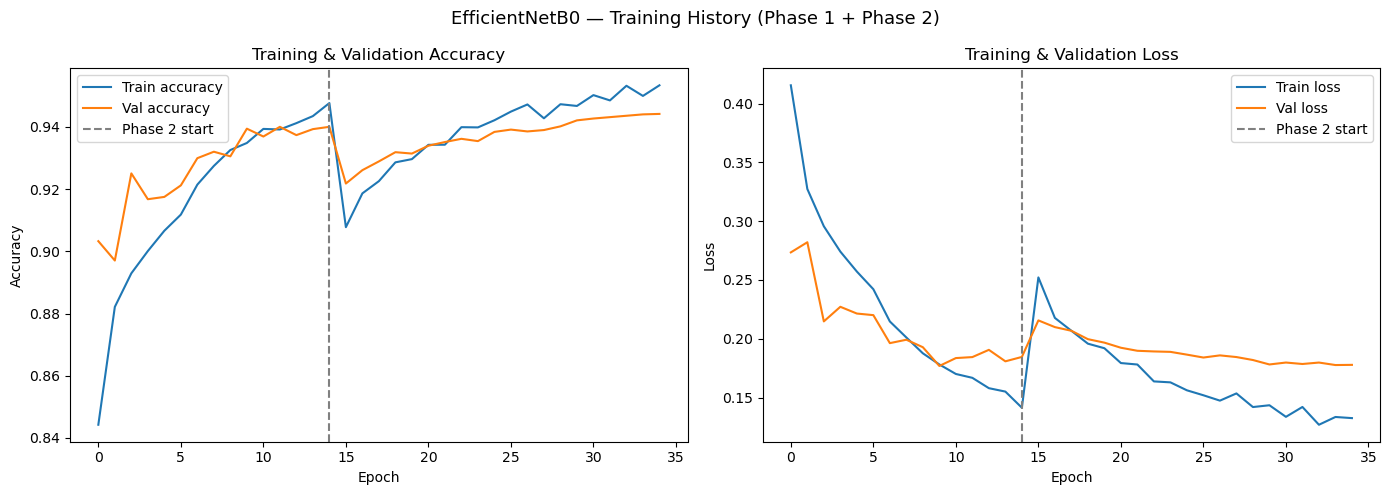

In [15]:
# ════════════════════════════════════════════════════════════
# STEP 6 — PLOT TRAINING HISTORY
# ════════════════════════════════════════════════════════════
def plot_history(h1, h2, metric, ax):
    full_train  = h1.history[metric] + h2.history[metric]
    full_val    = h1.history[f"val_{metric}"] + h2.history[f"val_{metric}"]
    split_epoch = len(h1.history[metric])

    ax.plot(full_train, label=f"Train {metric}")
    ax.plot(full_val,   label=f"Val {metric}")
    ax.axvline(x=split_epoch - 1, color="gray", linestyle="--", label="Phase 2 start")
    ax.set_xlabel("Epoch")
    ax.set_ylabel(metric.capitalize())
    ax.set_title(f"Training & Validation {metric.capitalize()}")
    ax.legend()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plot_history(history1, history2, "accuracy", ax1)
plot_history(history1, history2, "loss", ax2)
plt.suptitle("EfficientNetB0 — Training History (Phase 1 + Phase 2)", fontsize=13)
plt.tight_layout()
plt.show()


Evaluating on Test Data...
211/211 ━━━━━━━━━━━━━━━━━━━━ 72s 340ms/step - accuracy: 0.9441 - loss: 0.1778
Final Test Accuracy: 94.41%
Generating predictions...
211/211 ━━━━━━━━━━━━━━━━━━━━ 75s 347ms/step

--- Classification Report ---
                precision    recall  f1-score   support

Non-Recyclable       0.81      0.95      0.87       970
       Organic       0.97      0.95      0.96      2794
    Recyclable       0.97      0.94      0.95      2985

      accuracy                           0.94      6749
     macro avg       0.92      0.94      0.93      6749
  weighted avg       0.95      0.94      0.95      6749


--- Confusion Matrix ---


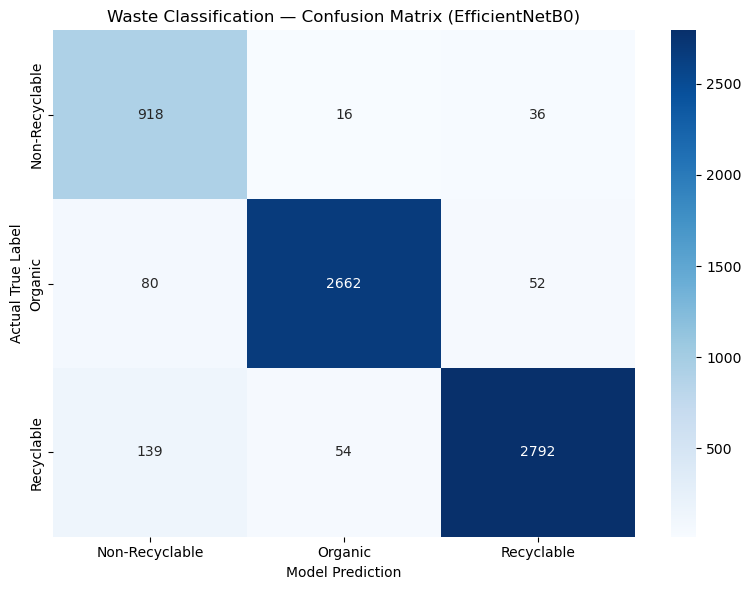

In [16]:
# ════════════════════════════════════════════════════════════
# STEP 7 — EVALUATION
# ════════════════════════════════════════════════════════════
print("\nEvaluating on Test Data...")
test_loss, test_accuracy = model.evaluate(test_gen)
print(f"Final Test Accuracy: {test_accuracy * 100:.2f}%")

true_labels = test_gen.classes
print("Generating predictions...")
predictions      = model.predict(test_gen)
predicted_labels = np.argmax(predictions, axis=1)

print("\n--- Classification Report ---")
print(classification_report(true_labels, predicted_labels, target_names=DISPLAY_NAMES))

print("\n--- Confusion Matrix ---")
cm = confusion_matrix(true_labels, predicted_labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=DISPLAY_NAMES, yticklabels=DISPLAY_NAMES)
plt.title("Waste Classification — Confusion Matrix (EfficientNetB0)")
plt.ylabel("Actual True Label")
plt.xlabel("Model Prediction")
plt.tight_layout()
plt.show()

In [17]:
# ════════════════════════════════════════════════════════════
# STEP 8 — SAVE MODEL
# ════════════════════════════════════════════════════════════
print(f"\nSaving to: {os.path.abspath(MODEL_SAVE_PATH)}")
model.save(MODEL_SAVE_PATH)
print(f"Model saved as '{MODEL_SAVE_PATH}' ✅")


Saving to: C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\waste_efficientnetb0_final(split).keras
Model saved as 'C:\Users\Adit Gupta\OneDrive\Desktop\sem 4\practicum\waste_efficientnetb0_final(split).keras' ✅
